# Appendix A in code: block encoding the 1D Poisson operator

Companion notebook to *Structured Block Encoding of the Finite Element
Elasticity Operator*, Appendix A.

Appendix A works the smallest interesting case by hand: the 1D finite element
Poisson operator $\mathbf{K}_1$ on $N=4$ nodes, under three boundary
treatments. This notebook regenerates every number in that appendix and, at
the end, assembles the block-encoding unitary explicitly and checks that its
top-left block really is $\mathbf{K}_1/\alpha$.

Nothing here is approximate. Every claim is asserted, so if a cell runs, the
claim holds to machine precision.

**Contents**

1. Shift and reflection operators
2. The three forms of $\mathbf{K}_1$
3. LCU coefficients (Table 6) and reading them back
4. Why $\alpha$ does not change
5. Verification against direct finite element assembly
6. The block encoding: PREP, SELECT, PREP$^\dagger$
7. How tight is $\alpha$?
8. The load vector
9. Exercises

Requires only `numpy` and `matplotlib`.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

np.set_printoptions(precision=4, suppress=True, linewidth=120)

m = 2              # qubits per spatial direction
N = 2 ** m         # nodes: N = 4
h = 1.0            # element size; K_1 is independent of h in 1D
print(f"{N} nodes, {m} system qubits")

4 nodes, 2 system qubits


## 1. Shift and reflection operators

Two families of unitaries generate everything.

The **cyclic shift** $S_c : |j\rangle \mapsto |(j+1) \bmod N\rangle$ and its
adjoint $S_c^\dagger$ move the grid by one node. As circuits they are
increment/decrement gates, $\mathcal{O}(m)$ deep.

The **reflection** about a set $A$ of grid indices,

$$R_A = I - 2\sum_{j \in A} |j\rangle\langle j|,$$

is a diagonal $\pm 1$ unitary — an $m$-controlled $Z$ conjugated by $X$ gates
for a single index. The identity that makes it useful is

$$\tfrac12 (R_j + I) = I - |j\rangle\langle j| = \Pi_j^{\perp},$$

a reflection turned into the projector that deletes row $j$.

In [2]:
def shift(N, k=1):
    """Cyclic shift S_c^k : |j> -> |(j+k) mod N>."""
    S = np.zeros((N, N))
    for j in range(N):
        S[(j + k) % N, j] = 1.0
    return S

def reflection(N, idx):
    """R_A = I - 2 sum_{j in A} |j><j|."""
    R = np.eye(N)
    for j in np.atleast_1d(idx):
        R[j, j] = -1.0
    return R

I   = np.eye(N)
Sc  = shift(N, 1)
Scd = Sc.T                      # S_c^dagger = S_c^{-1}
R0  = reflection(N, 0)
R3  = reflection(N, N - 1)

# every operator below is a real linear combination of these seven
U = {"I": I, "Sc": Sc, "R0.Sc": R0 @ Sc, "Sc'": Scd, "R3.Sc'": R3 @ Scd,
     "R0": R0, "R3": R3}

for name, M in U.items():
    assert np.allclose(M @ M.T, I), name          # all unitary
print("S_c =\n", Sc)
print("\nhalf(R0 + I) deletes row 0:\n", 0.5 * (R0 + I))

S_c =
 [[0. 0. 0. 1.]
 [1. 0. 0. 0.]
 [0. 1. 0. 0.]
 [0. 0. 1. 0.]]

half(R0 + I) deletes row 0:
 [[0. 0. 0. 0.]
 [0. 1. 0. 0.]
 [0. 0. 1. 0.]
 [0. 0. 0. 1.]]


Note which row each shift wraps into. $S_c$ has a single wrap entry in row
$0$; $S_c^\dagger$ wraps into row $N-1$. That fact — a property of the shift
alone, not of any coefficient multiplying it — is what makes the boundary
treatment below work for *every* operator that is a Laurent polynomial in
$S_c$, the finite element mass and gradient factors included.

## 2. The three forms of $\mathbf{K}_1$

Appendix A, Equation (49). Reading down: applying essential conditions zeroes
the two corner couplings, and the traction-free correction halves the boundary
diagonal.

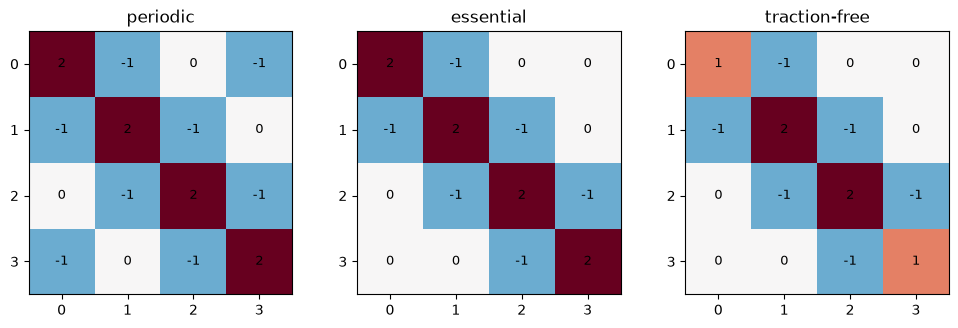

In [3]:
K_per  = np.array([[ 2, -1,  0, -1],
                   [-1,  2, -1,  0],
                   [ 0, -1,  2, -1],
                   [-1,  0, -1,  2]], float)

K_ess  = np.array([[ 2, -1,  0,  0],
                   [-1,  2, -1,  0],
                   [ 0, -1,  2, -1],
                   [ 0,  0, -1,  2]], float)

K_free = np.array([[ 1, -1,  0,  0],
                   [-1,  2, -1,  0],
                   [ 0, -1,  2, -1],
                   [ 0,  0, -1,  1]], float)

TARGET = {"periodic": K_per, "essential": K_ess, "traction-free": K_free}

fig, axes = plt.subplots(1, 3, figsize=(10, 3.2))
for ax, (name, K) in zip(axes, TARGET.items()):
    ax.imshow(K, cmap="RdBu_r", vmin=-2, vmax=2)
    for i in range(N):
        for j in range(N):
            ax.text(j, i, f"{K[i,j]:.0f}", ha="center", va="center", fontsize=9)
    ax.set_title(name); ax.set_xticks(range(N)); ax.set_yticks(range(N))
plt.tight_layout(); plt.show()

## 3. LCU coefficients

Table 6 of the paper. Each operator is written as $\sum_k c_k U_k$ over the
seven unitaries of Section 1, and $\alpha = \sum_k |c_k|$ is the
subnormalization the block encoding pays.

The essential form comes from the substitution

$$S_c \longmapsto \tfrac12 (R_0 + I) S_c, \qquad
  S_c^\dagger \longmapsto \tfrac12 (R_{N-1} + I) S_c^\dagger,$$

which splits each shift into two halves of equal magnitude. The traction-free
form adds a diagonal correction, handled in Section 4.

In [4]:
LCU = {
    "periodic": {
        "I": 2.0, "Sc": -1.0, "Sc'": -1.0},
    "essential": {
        "I": 2.0, "Sc": -0.5, "R0.Sc": -0.5, "Sc'": -0.5, "R3.Sc'": -0.5},
    "traction-free": {
        "I": 1.0, "Sc": -0.5, "R0.Sc": -0.5, "Sc'": -0.5, "R3.Sc'": -0.5,
        "R0": 0.5, "R3": 0.5},
}

def dense(terms):
    """Sum_k c_k U_k."""
    return sum(c * U[k] for k, c in terms.items())

def alpha(terms):
    """Subnormalization alpha = sum_k |c_k|."""
    return sum(abs(c) for c in terms.values())

# reproduce Table 6
cols = list(U)
head = f"{'':<15}" + "".join(f"{k:>9}" for k in cols) + f"{'L':>5}{'alpha':>8}"
print(head); print("-" * len(head))
for name, t in LCU.items():
    row = "".join(f"{t[k]:>9.2f}" if k in t else f"{'--':>9}" for k in cols)
    print(f"{name:<15}{row}{len(t):>5}{alpha(t):>8.1f}")

                       I       Sc    R0.Sc      Sc'   R3.Sc'       R0       R3    L   alpha
-------------------------------------------------------------------------------------------
periodic            2.00    -1.00       --    -1.00       --       --       --    3     4.0
essential           2.00    -0.50    -0.50    -0.50    -0.50       --       --    5     4.0
traction-free       1.00    -0.50    -0.50    -0.50    -0.50     0.50     0.50    7     4.0


Each row is read back as an operator. For the essential case this is
Equation (51),

$$\mathbf{K}_1^{\mathrm{ess}} = 2I
  - \tfrac12 S_c - \tfrac12 R_0 S_c
  - \tfrac12 S_c^\dagger - \tfrac12 R_3 S_c^\dagger .$$

The mechanism is worth seeing directly: $R_0$ flips the sign of the single
entry that $S_c$ wraps into row $0$, so that entry cancels against the plain
$S_c$ term and the corner coupling vanishes. Every other entry receives
$-\tfrac12$ from each of the two terms and is unchanged.

In [5]:
for name, t in LCU.items():
    err = np.abs(dense(t) - TARGET[name]).max()
    print(f"{name:<15} max|LCU - target| = {err:.2e}")
    assert err < 1e-14

# the cancellation, entry by entry
print("\n-1/2 * Sc:\n", -0.5 * Sc)
print("\n-1/2 * R0.Sc:\n", -0.5 * R0 @ Sc)
print("\nsum (corner entry [0,3] is gone):\n", -0.5 * Sc - 0.5 * R0 @ Sc)

periodic        max|LCU - target| = 0.00e+00
essential       max|LCU - target| = 0.00e+00
traction-free   max|LCU - target| = 0.00e+00

-1/2 * Sc:
 [[-0.  -0.  -0.  -0.5]
 [-0.5 -0.  -0.  -0. ]
 [-0.  -0.5 -0.  -0. ]
 [-0.  -0.  -0.5 -0. ]]

-1/2 * R0.Sc:
 [[ 0.   0.   0.   0.5]
 [-0.5  0.   0.   0. ]
 [ 0.  -0.5  0.   0. ]
 [ 0.   0.  -0.5  0. ]]

sum (corner entry [0,3] is gone):
 [[-0. -0. -0.  0.]
 [-1. -0. -0. -0.]
 [-0. -1. -0. -0.]
 [-0. -0. -1. -0.]]


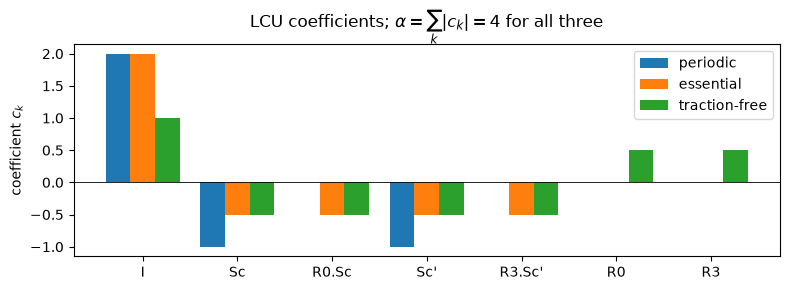

In [6]:
fig, ax = plt.subplots(figsize=(8, 3))
w, xs = 0.26, np.arange(len(cols))
for i, (name, t) in enumerate(LCU.items()):
    ax.bar(xs + (i - 1) * w, [t.get(k, 0.0) for k in cols], w, label=name)
ax.set_xticks(xs); ax.set_xticklabels(cols); ax.axhline(0, color="k", lw=0.6)
ax.set_ylabel("coefficient $c_k$")
ax.set_title(r"LCU coefficients; $\alpha=\sum_k|c_k|=4$ for all three")
ax.legend(); plt.tight_layout(); plt.show()

## 4. Why $\alpha$ does not change

This is the point of the whole construction, so it is worth isolating.

Splitting a shift replaces one coefficient $c$ by two of magnitude $|c|/2$, so
its contribution to $\alpha$ is unchanged. The traction-free correction is the
one that could have cost something: it subtracts the projector pair

$$-(\Pi_0 + \Pi_3) = -\tfrac12 (I - R_0 R_3) = -I + \tfrac12 R_0 + \tfrac12 R_3 ,$$

which drops the identity coefficient from $2$ to $1$ (saving $1$) and adds two
reflection terms of magnitude $\tfrac12$ (costing $1$). The two exactly
offset.

In [7]:
Pi0 = np.zeros((N, N)); Pi0[0, 0] = 1.0
Pi3 = np.zeros((N, N)); Pi3[N-1, N-1] = 1.0

lhs = -(Pi0 + Pi3)
rhs = -0.5 * (I - R0 @ R3)
alt = -I + 0.5 * R0 + 0.5 * R3
assert np.allclose(lhs, rhs) and np.allclose(lhs, alt)
print("-(Pi_0 + Pi_3) three ways: identical\n", lhs)

print("\nalpha bookkeeping for the traction-free correction")
print(f"  identity coefficient 2 -> 1        saves  {1.0}")
print(f"  two reflections at magnitude 1/2   costs  {2 * 0.5}")
print(f"  net change in alpha:               {1.0 - 2 * 0.5}")
for name, t in LCU.items():
    assert abs(alpha(t) - 4.0) < 1e-14
print("\nalpha = 4 for all three boundary treatments, with L = 3, 5, 7 terms.")

-(Pi_0 + Pi_3) three ways: identical
 [[-1. -0. -0. -0.]
 [-0. -0. -0. -0.]
 [-0. -0. -0. -0.]
 [-0. -0. -0. -1.]]

alpha bookkeeping for the traction-free correction
  identity coefficient 2 -> 1        saves  1.0
  two reflections at magnitude 1/2   costs  1.0
  net change in alpha:               0.0

alpha = 4 for all three boundary treatments, with L = 3, 5, 7 terms.


## 5. Verification against direct finite element assembly

The LCU is only worth anything if it reproduces the operator a finite element
code would actually assemble. Linear elements on unit intervals, element
matrix $\begin{pmatrix} 1 & -1 \\ -1 & 1\end{pmatrix}$.

One subtlety. The **essential** form is the periodic operator with the wrap
deleted; its boundary diagonal is still $2$, not $1$. That is deliberate —
those rows are removed by the constraint, so their diagonal never enters the
solve. It agrees with the directly assembled open-mesh operator *after*
restriction to the free nodes, which is the only place it is used.

In [8]:
def assemble_1d(N, periodic):
    """Direct FE assembly, linear elements."""
    Ke = np.array([[1.0, -1.0], [-1.0, 1.0]])
    K  = np.zeros((N, N))
    for e in range(N if periodic else N - 1):
        n = [e, (e + 1) % N]
        for a in range(2):
            for b in range(2):
                K[n[a], n[b]] += Ke[a, b]
    return K

K_direct_per  = assemble_1d(N, periodic=True)
K_direct_open = assemble_1d(N, periodic=False)

print("periodic      vs direct :", np.abs(K_per  - K_direct_per ).max())
print("traction-free vs direct :", np.abs(K_free - K_direct_open).max())

free_nodes = [1, 2]                      # clamp nodes 0 and N-1
ii = np.ix_(free_nodes, free_nodes)
print("essential     vs direct, restricted to free nodes :",
      np.abs(K_ess[ii] - K_direct_open[ii]).max())
print("\nrestricted operator:\n", K_ess[ii])

assert np.allclose(K_per, K_direct_per)
assert np.allclose(K_free, K_direct_open)
assert np.allclose(K_ess[ii], K_direct_open[ii])

periodic      vs direct : 0.0
traction-free vs direct : 0.0
essential     vs direct, restricted to free nodes : 0.0

restricted operator:
 [[ 2. -1.]
 [-1.  2.]]


## 6. The block encoding

An $(\alpha, a)$-block encoding of $\mathbf{A}$ is a unitary $\mathcal{U}$ on
$a$ ancilla plus $m$ system qubits whose top-left block is $\mathbf{A}/\alpha$:

$$\bigl(\langle 0|^{\otimes a} \otimes I\bigr)\,\mathcal{U}\,
  \bigl(|0\rangle^{\otimes a} \otimes I\bigr) = \mathbf{A}/\alpha .$$

The LCU recipe builds it as $\mathcal{U} = \mathsf{P}^\dagger \mathsf{S} \mathsf{P}$:

- **PREP** loads $|0\rangle \mapsto \frac{1}{\sqrt\alpha}\sum_k \sqrt{|c_k|}\,|k\rangle$
- **SELECT** applies $\mathrm{sign}(c_k)\,U_k$ to the system conditioned on $|k\rangle$
- **PREP$^\dagger$** un-computes the ancilla

Signs are absorbed into the unitaries, which is legitimate because every $U_k$
here is real, so $\mathrm{sign}(c_k)U_k$ is still unitary. Ancilla states
beyond $L$ are padding: zero amplitude, identity in SELECT.

We build all three as explicit matrices. With $L = 7$ the essential and
traction-free cases need $a = 3$ ancilla qubits, so $\mathcal{U}$ is
$2^{3+2} = 32$ square — small enough to look at.

In [9]:
def prep_unitary(coeffs, n_anc):
    """Any unitary whose first column is sqrt(|c_k|/alpha)."""
    dim = 2 ** n_anc
    v = np.zeros(dim)
    v[:len(coeffs)] = np.sqrt(np.abs(coeffs) / sum(np.abs(coeffs)))
    M = np.eye(dim); M[:, 0] = v
    Q, R = np.linalg.qr(M)
    return Q * np.sign(np.diag(R))          # fix QR sign convention

def block_encoding(terms):
    keys  = list(terms)
    c     = np.array([terms[k] for k in keys])
    L     = len(keys)
    n_anc = max(1, int(np.ceil(np.log2(L))))
    dim_a = 2 ** n_anc

    P = prep_unitary(c, n_anc)

    SEL = np.zeros((dim_a * N, dim_a * N))
    for k in range(dim_a):
        proj = np.zeros((dim_a, dim_a)); proj[k, k] = 1.0
        Uk = np.sign(c[k]) * U[keys[k]] if k < L else I     # padding -> identity
        SEL += np.kron(proj, Uk)

    Ublk = np.kron(P.conj().T, I) @ SEL @ np.kron(P, I)
    return Ublk, n_anc

for name, t in LCU.items():
    Ublk, n_anc = block_encoding(t)
    top  = Ublk[:N, :N]                     # <0|_anc U |0>_anc
    err  = np.abs(top - dense(t) / alpha(t)).max()
    unit = np.abs(Ublk @ Ublk.T - np.eye(Ublk.shape[0])).max()
    print(f"{name:<15} L={len(t)}  a={n_anc}  total qubits={n_anc + m}  "
          f"dim={Ublk.shape[0]:3d}  |top - K/alpha|={err:.1e}  "
          f"|UU^T - I|={unit:.1e}")
    assert err < 1e-13 and unit < 1e-13

periodic        L=3  a=2  total qubits=4  dim= 16  |top - K/alpha|=1.1e-16  |UU^T - I|=5.6e-16
essential       L=5  a=3  total qubits=5  dim= 32  |top - K/alpha|=1.1e-16  |UU^T - I|=3.3e-16
traction-free   L=7  a=3  total qubits=5  dim= 32  |top - K/alpha|=5.6e-17  |UU^T - I|=6.7e-16


top-left block, alpha * <0|U|0>  (should be K_ess):
 [[ 2. -1.  0.  0.]
 [-1.  2. -1.  0.]
 [ 0. -1.  2. -1.]
 [ 0.  0. -1.  2.]]


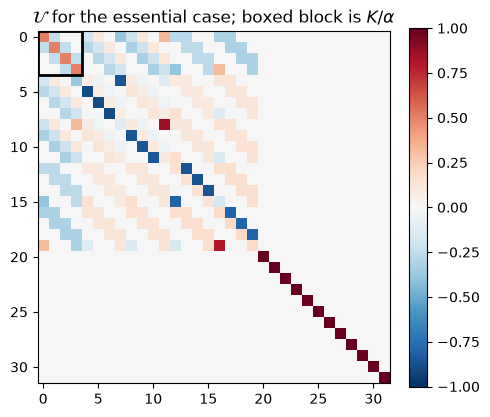

In [10]:
# look at the essential case in full
Ublk, n_anc = block_encoding(LCU["essential"])
print("top-left block, alpha * <0|U|0>  (should be K_ess):\n",
      alpha(LCU["essential"]) * Ublk[:N, :N])

fig, ax = plt.subplots(figsize=(5, 5))
im = ax.imshow(Ublk, cmap="RdBu_r", vmin=-1, vmax=1)
ax.add_patch(plt.Rectangle((-0.5, -0.5), N, N, fill=False, lw=2, ec="k"))
ax.set_title(r"$\mathcal{U}$ for the essential case; boxed block is $K/\alpha$")
plt.colorbar(im, fraction=0.046); plt.tight_layout(); plt.show()

## 7. How tight is $\alpha$?

$\alpha$ is an $\ell_1$ quantity; algorithm cost is governed by
$\|\mathbf{A}\|_2$. The gap splits as

$$\frac{\alpha}{\|\mathbf{A}\|_2}
 = \underbrace{\frac{\alpha}{\|\mathbf{A}\|_\infty}}_{\text{encoding}}
   \cdot
   \underbrace{\frac{\|\mathbf{A}\|_\infty}{\|\mathbf{A}\|_2}}_{\text{operator}}$$

because $\|\mathbf{A}\|_\infty$, the largest absolute row sum, is the sharpest
bound an $\ell_1$ coefficient sum can reach. For 1D Poisson the first factor
is exactly $1$: the encoding is optimal among *all* LCU decompositions, and
what is left is the operator's own $\ell_\infty$–$\ell_2$ gap, which vanishes
as $N$ grows.

In [11]:
def factors_1d(n_qubits, kind):
    """Rebuild the LCU at larger N so the trend is visible."""
    Nn = 2 ** n_qubits
    Ie, S = np.eye(Nn), shift(Nn, 1)
    Ra, Rb = reflection(Nn, 0), reflection(Nn, Nn - 1)
    if kind == "periodic":
        t = {"I": 2.0, "S": -1.0, "Sd": -1.0}
    elif kind == "essential":
        t = {"I": 2.0, "S": -.5, "RS": -.5, "Sd": -.5, "RSd": -.5}
    else:
        t = {"I": 1.0, "S": -.5, "RS": -.5, "Sd": -.5, "RSd": -.5,
             "Ra": .5, "Rb": .5}
    B = {"I": Ie, "S": S, "RS": Ra @ S, "Sd": S.T, "RSd": Rb @ S.T,
         "Ra": Ra, "Rb": Rb}
    K = sum(c * B[k] for k, c in t.items())
    return K, sum(abs(c) for c in t.values())

rows = []
for mm in range(2, 8):
    for kind in LCU:
        K, a = factors_1d(mm, kind)
        n2, ninf = np.linalg.norm(K, 2), np.abs(K).sum(1).max()
        rows.append((mm, 2 ** mm, kind, a, n2, ninf, a / ninf, a / n2))

print(f"{'N':>5} {'case':<15}{'alpha':>7}{'||K||_2':>9}{'||K||_inf':>10}"
      f"{'a/inf':>8}{'a/2':>8}")
for mm, Nn, kind, a, n2, ninf, ri, r2 in rows:
    print(f"{Nn:>5} {kind:<15}{a:>7.3f}{n2:>9.4f}{ninf:>10.3f}{ri:>8.4f}{r2:>8.4f}")
    assert abs(ri - 1.0) < 1e-12, "alpha should equal ||K||_inf exactly"

    N case             alpha  ||K||_2 ||K||_inf   a/inf     a/2
    4 periodic         4.000   4.0000     4.000  1.0000  1.0000
    4 essential        4.000   3.6180     4.000  1.0000  1.1056
    4 traction-free    4.000   3.4142     4.000  1.0000  1.1716
    8 periodic         4.000   4.0000     4.000  1.0000  1.0000
    8 essential        4.000   3.8794     4.000  1.0000  1.0311
    8 traction-free    4.000   3.8478     4.000  1.0000  1.0396
   16 periodic         4.000   4.0000     4.000  1.0000  1.0000
   16 essential        4.000   3.9659     4.000  1.0000  1.0086
   16 traction-free    4.000   3.9616     4.000  1.0000  1.0097
   32 periodic         4.000   4.0000     4.000  1.0000  1.0000
   32 essential        4.000   3.9909     4.000  1.0000  1.0023
   32 traction-free    4.000   3.9904     4.000  1.0000  1.0024
   64 periodic         4.000   4.0000     4.000  1.0000  1.0000
   64 essential        4.000   3.9977     4.000  1.0000  1.0006
   64 traction-free    4.000   3.9976   

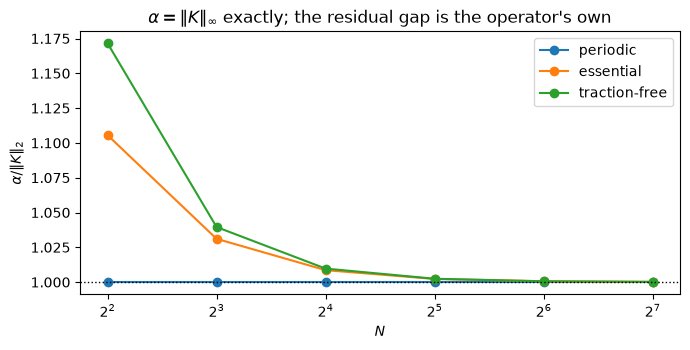

In [12]:
fig, ax = plt.subplots(figsize=(7, 3.6))
for kind in LCU:
    xs = [r[1] for r in rows if r[2] == kind]
    ax.plot(xs, [r[7] for r in rows if r[2] == kind], "o-", label=kind)
ax.axhline(1.0, color="k", ls=":", lw=1)
ax.set_xscale("log", base=2); ax.set_xlabel("$N$")
ax.set_ylabel(r"$\alpha / \|K\|_2$")
ax.set_title(r"$\alpha=\|K\|_\infty$ exactly; the residual gap is the operator's own")
ax.legend(); plt.tight_layout(); plt.show()

## 8. The load vector

For $-u'' = f$ with a prescribed flux $u'(1) = g$ at the right end, the natural
condition contributes $g$ at the last node only:

$$\mathbf{f} = \mathbf{M}_1 \mathbf{f}_{\mathrm{int}} + g\,\mathbf{e}_{N-1}.$$

A prescribed non-zero Neumann condition is a *natural* condition: it enters
through the right-hand side, so the operator stays the traction-free one and
only the load changes. The consistent mass matrix $\mathbf{M}_1$ expands over
the same seven unitaries at $\alpha = 1$.

In [13]:
M_LCU = {
    "periodic":      {"I": 4/6, "Sc": 1/6, "Sc'": 1/6},
    "essential":     {"I": 4/6, "Sc": 1/12, "R0.Sc": 1/12,
                      "Sc'": 1/12, "R3.Sc'": 1/12},
    "traction-free": {"I": 1/3, "Sc": 1/12, "R0.Sc": 1/12,
                      "Sc'": 1/12, "R3.Sc'": 1/12, "R0": 1/6, "R3": 1/6},
}
for name, t in M_LCU.items():
    print(f"{name:<15} alpha_M = {alpha(t):.4f}   6*M =")
    print(6 * dense(t))
    assert abs(alpha(t) - 1.0) < 1e-14

# M_free must equal the direct open-mesh mass assembly
Me = np.array([[2.0, 1.0], [1.0, 2.0]]) / 6
M_direct = np.zeros((N, N))
for e in range(N - 1):
    for a_ in range(2):
        for b_ in range(2):
            M_direct[e + a_, e + b_] += Me[a_, b_]
assert np.allclose(dense(M_LCU["traction-free"]), M_direct)
print("traction-free M_1 matches direct assembly.")

g = 1.0
f_int = np.ones(N)
f = dense(M_LCU["traction-free"]) @ f_int + g * np.eye(N)[N - 1]
print("\nload vector f =", f)

periodic        alpha_M = 1.0000   6*M =
[[4. 1. 0. 1.]
 [1. 4. 1. 0.]
 [0. 1. 4. 1.]
 [1. 0. 1. 4.]]
essential       alpha_M = 1.0000   6*M =
[[4. 1. 0. 0.]
 [1. 4. 1. 0.]
 [0. 1. 4. 1.]
 [0. 0. 1. 4.]]
traction-free   alpha_M = 1.0000   6*M =
[[2. 1. 0. 0.]
 [1. 4. 1. 0.]
 [0. 1. 4. 1.]
 [0. 0. 1. 2.]]
traction-free M_1 matches direct assembly.

load vector f = [0.5 1.  1.  1.5]


## 9. Exercises

1. **Move the constraint.** Clamp only the left node. The right end is then
   free, so it takes the one-sided correction $-\Pi_{N-1} = -\tfrac12(I - R_{N-1})$
   while the left end keeps its full diagonal. Show that the basis grows to
   six unitaries and that $\alpha$ is still $4$.

2. **Two dimensions.** Build
   $\mathbf{K}_{2D} = \mathbf{K}_1 \otimes \mathbf{M}_1 + \mathbf{M}_1 \otimes \mathbf{K}_1$
   by merging coefficients that land on the same pair of shifts. Recover
   $L_{2D} = 9, 25, 49$ and $\alpha_{2D} = 16/3$ (Appendix B).

3. **Mix the directions.** Clamp left and right, leave top and bottom free.
   Use $\mathbf{K}_1^{\mathrm{ess}}$ and $\mathbf{M}_1^{\mathrm{ess}}$ in the
   $x$ slot and the free forms in the $y$ slot; check against a direct $Q_4$
   assembly after removing the clamped columns. Then substitute the essential
   forms in the $y$ slot as well and find the $\tfrac43$ discrepancy the paper
   warns about.

4. **Where the bound bites.** Section 7 shows $\alpha = \|K\|_\infty$ exactly
   for Poisson. For 2D elasticity the ratio is $1.18$–$1.22$. Build the
   $\{I, Z, X\}$ decomposition and find the rows where the $I$ and $Z$
   components partially cancel — that cancellation is what the $\ell_1$ sum
   cannot see.